In [2]:
import os
os.chdir('/home/che82/athan/pascode/github')
from PASCode import scACC
import numpy as np
import matplotlib.pyplot as plt

/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/umap/d

In [5]:
!pip install ipympl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 13.4 MB/s eta 0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 40.6 MB/s eta 0:00:00
  Using cached ipython_genutils-0.2.0-py2.py3-none-any.whl (26 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.4 MB/s eta 0:00:0031m58.8 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.2/198.2 kB 41.7 MB/s eta 0:00:00


In [6]:
# %matplotlib inline
%matplotlib widget

In [7]:
X = np.concatenate([np.random.rand(500, 500), np.random.rand(500, 500) + 2])
y = np.concatenate([np.random.choice([0, 1], size=500, p=[0.05, 0.95]), 
                   np.random.choice([0, 1], size=500, p=[0.95, 0.05])])
sample_ids = np.random.choice(11, size=1000, replace=True)

<Axes: >

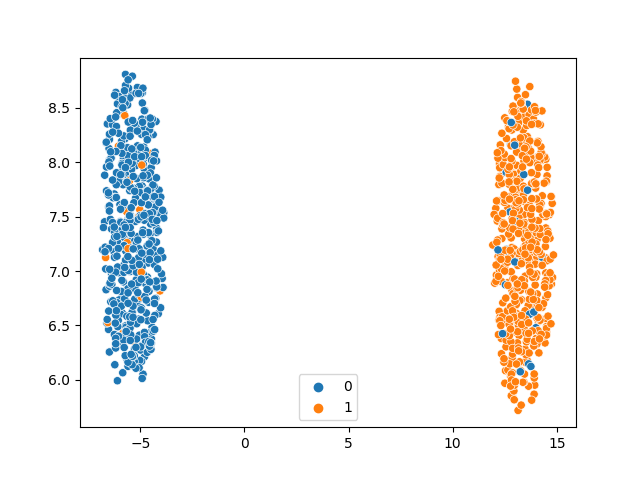

In [8]:
import umap
import seaborn as sns
umap_emb = umap.UMAP().fit_transform(X, )
sns.scatterplot(x=umap_emb[:,0], y=umap_emb[:,1], hue=y)

In [9]:
model = scACC()
model.train(X_train=X, y_train=y, batch_size=256)

In [5]:
# use manually set parameters
model = scACC(latent_dim=3, 
              n_clusters=30, 
              lambda_cluster=1, 
              lambda_phenotype=1, 
              device='cuda', 
              alpha=1,
              dropout=.2)
model.train(X_train=X, 
            y_train=y, 
            epoch_pretrain=15,
            epoch_train=15,
            batch_size=256,
            lr_pretrain=1e-3,
            lr_train=1e-3,
            require_pretrain_phase=True,
            require_train_phase=True,
            evaluation=False, # evaluate on test data. must be set to True when plot_evaluation is set to True
            plot_evaluation=False, # plot metics per epoch
            id_train=None, X_test=None, y_test=None, id_test=None, # used when plot_evaluation is set to True
            fold_num=None) # print out fold num in cross validation

In [10]:
z = model.get_latent_space(X)

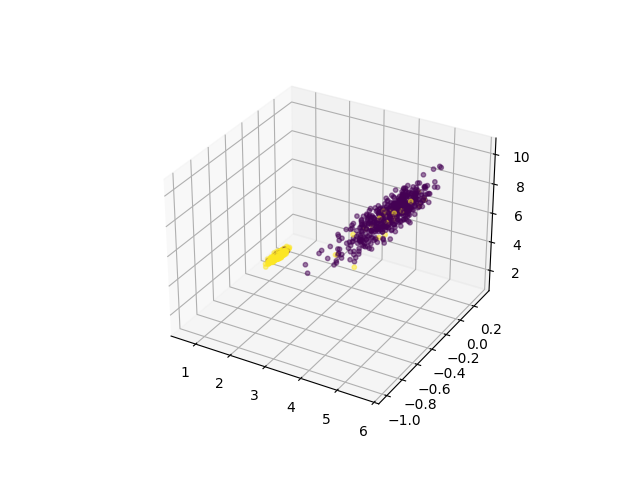

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(z[:,0], z[:,1], z[:,2], c=y, s=10, alpha=0.5)
plt.show()

In [12]:
model.get_cluster_abundance_matrix(X, sample_ids=sample_ids)

cluster,0,6,10,13,16,18,22,24,28
sample_ids,,,,,,,,,
0,0.041237,0.000000,0.412371,0.257732,0.000000,0.030928,0.000000,0.000000,0.257732
1,0.046512,0.000000,0.430233,0.244186,0.000000,0.000000,0.023256,0.011628,0.244186
2,0.011905,0.000000,0.428571,0.190476,0.000000,0.047619,0.011905,0.011905,0.297619
3,0.038462,0.012821,0.500000,0.141026,0.000000,0.051282,0.000000,0.000000,0.256410
4,0.060241,0.000000,0.469880,0.192771,0.000000,0.048193,0.000000,0.024096,0.204819
5,0.031915,0.000000,0.489362,0.223404,0.000000,0.042553,0.000000,0.000000,0.212766
6,0.031250,0.000000,0.458333,0.218750,0.000000,0.041667,0.010417,0.010417,0.229167
7,0.032609,0.000000,0.543478,0.119565,0.000000,0.032609,0.010870,0.000000,0.260870
8,0.019048,0.000000,0.428571,0.266667,0.009524,0.028571,0.009524,0.009524,0.228571


In [13]:
model.get_cluster_assignments(X)

array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10,  0, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        0, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0, 10, 10, 10,  6,
       10, 10, 10, 10, 10, 10, 10,  6, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0, 10, 10, 10,
       16, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10,  0,  0, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10,  0, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10,  0,  0, 10, 10, 10, 10,  0, 10,  0, 10, 10,  0, 10, 10, 10, 10,
       10, 10, 10, 10, 10

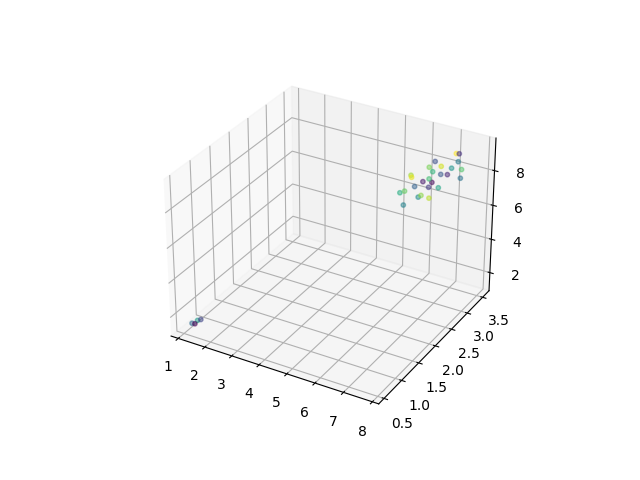

In [15]:
z = model.clusters.data
fig = plt.figure(projection='3d')
ax = fig.add_subplot(111, projection='3d')
ax.scatter(z[:,0], z[:,1], z[:,2], c=np.arange(30), s=10, alpha=0.5)
plt.show()